In [1]:
from weather_engine.database import engine
import pandas as pd
import xgboost as xgb
from weather_engine.llocv import load_fold, temporal_split_fold


FEATURES = ['rain', 'ws', 'stdwd', 'td', 'rh', 'tdmax', 'tdmin', 'u_vec', 'v_vec']

station_neighbors: pd.DataFrame = pd.read_sql("SELECT * FROM station_neighbors", engine)

In [2]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

all_X = []
all_y = []

all_data = pd.read_sql("SELECT * FROM clean_station_data", engine)
all_data['timestamp'] = pd.to_datetime(all_data['timestamp'])
all_data = all_data.set_index('timestamp').sort_index()
station_frames = {sid: grp.drop(columns='station_id') 
                  for sid, grp in all_data.groupby('station_id')}

for _, row in station_neighbors.iterrows():
    X, y = load_fold(
        int(row["station_id"]),
        int(row["neighbor_1_id"]),
        int(row["neighbor_2_id"]), 
        int(row["neighbor_3_id"]),
        station_frames=station_frames
    )
    all_X.append(X)
    all_y.append(y)
print("All folds loaded.")


all_X = pd.concat(all_X).sort_index()
all_y = pd.concat(all_y).sort_index()

X_train, X_val, y_train, y_val = temporal_split_fold(all_X, all_y)

models = {}
errors = {}

for feature in FEATURES:
    print(f"[{FEATURES.index(feature) + 1}/{len(FEATURES)}] Training RFSI for '{feature}'...", end=' ')
    objective = 'reg:tweedie' if feature == 'rain' else 'reg:squarederror'
    model = xgb.XGBRegressor(n_jobs=-1, objective=objective, tweedie_variance_power=1.5)
    model.fit(X_train, y_train[feature])
    preds = model.predict(X_val)
    mae = mean_absolute_error(y_val[feature], preds)
    rmse = root_mean_squared_error(y_val[feature], preds)
    errors[feature] = {'mae': mae, 'rmse': rmse}
    models[feature] = model
    print(f"MAE={mae:.4f}  RMSE={rmse:.4f}")



All folds loaded.
[1/9] Training RFSI for 'rain'... 

XGBoostError: [14:24:48] /workspace/src/objective/regression_obj.cu:673: TweedieRegression: label must be nonnegative
Stack trace:
  [bt] (0) /home/jadosh/repo/SparseData-AI-Precipitation-Forecasting/.venv/lib/python3.11/site-packages/xgboost/lib/libxgboost.so(+0x2bdf8c) [0x718fb46bdf8c]
  [bt] (1) /home/jadosh/repo/SparseData-AI-Precipitation-Forecasting/.venv/lib/python3.11/site-packages/xgboost/lib/libxgboost.so(+0x10511fd) [0x718fb54511fd]
  [bt] (2) /home/jadosh/repo/SparseData-AI-Precipitation-Forecasting/.venv/lib/python3.11/site-packages/xgboost/lib/libxgboost.so(+0x6f4a5a) [0x718fb4af4a5a]
  [bt] (3) /home/jadosh/repo/SparseData-AI-Precipitation-Forecasting/.venv/lib/python3.11/site-packages/xgboost/lib/libxgboost.so(XGBoosterUpdateOneIter+0x77) [0x718fb45caa67]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7b16) [0x719021dd9b16]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x43ef) [0x719021dd63ef]
  [bt] (6) /lib/x86_64-linux-gnu/libffi.so.8(ffi_call+0x12e) [0x719021dd90be

In [4]:
print((y_train['rain'] < 0).sum())
print(y_train['rain'].min())
print(y_train[y_train['rain'] < 0][['rain']].sort_values('rain').head(20))


46
-59994.0
                        rain
timestamp                   
2024-10-25 18:00:00 -59994.0
2024-10-25 19:00:00 -59994.0
2024-10-26 04:00:00 -59994.0
2024-10-26 05:00:00 -59994.0
2024-10-26 09:00:00 -59994.0
2024-10-26 06:00:00 -59994.0
2024-11-08 14:00:00 -59994.0
2024-11-08 13:00:00 -59994.0
2024-11-08 17:00:00 -59994.0
2024-11-12 01:00:00 -59994.0
2024-11-08 15:00:00 -59994.0
2024-11-08 16:00:00 -59994.0
2024-11-21 17:00:00 -59994.0
2024-11-24 07:00:00 -59994.0
2024-11-21 16:00:00 -59994.0
2024-11-12 02:00:00 -59994.0
2024-11-30 14:00:00 -59994.0
2024-11-30 23:00:00 -59994.0
2024-11-30 13:00:00 -59994.0
2024-11-24 08:00:00 -59994.0


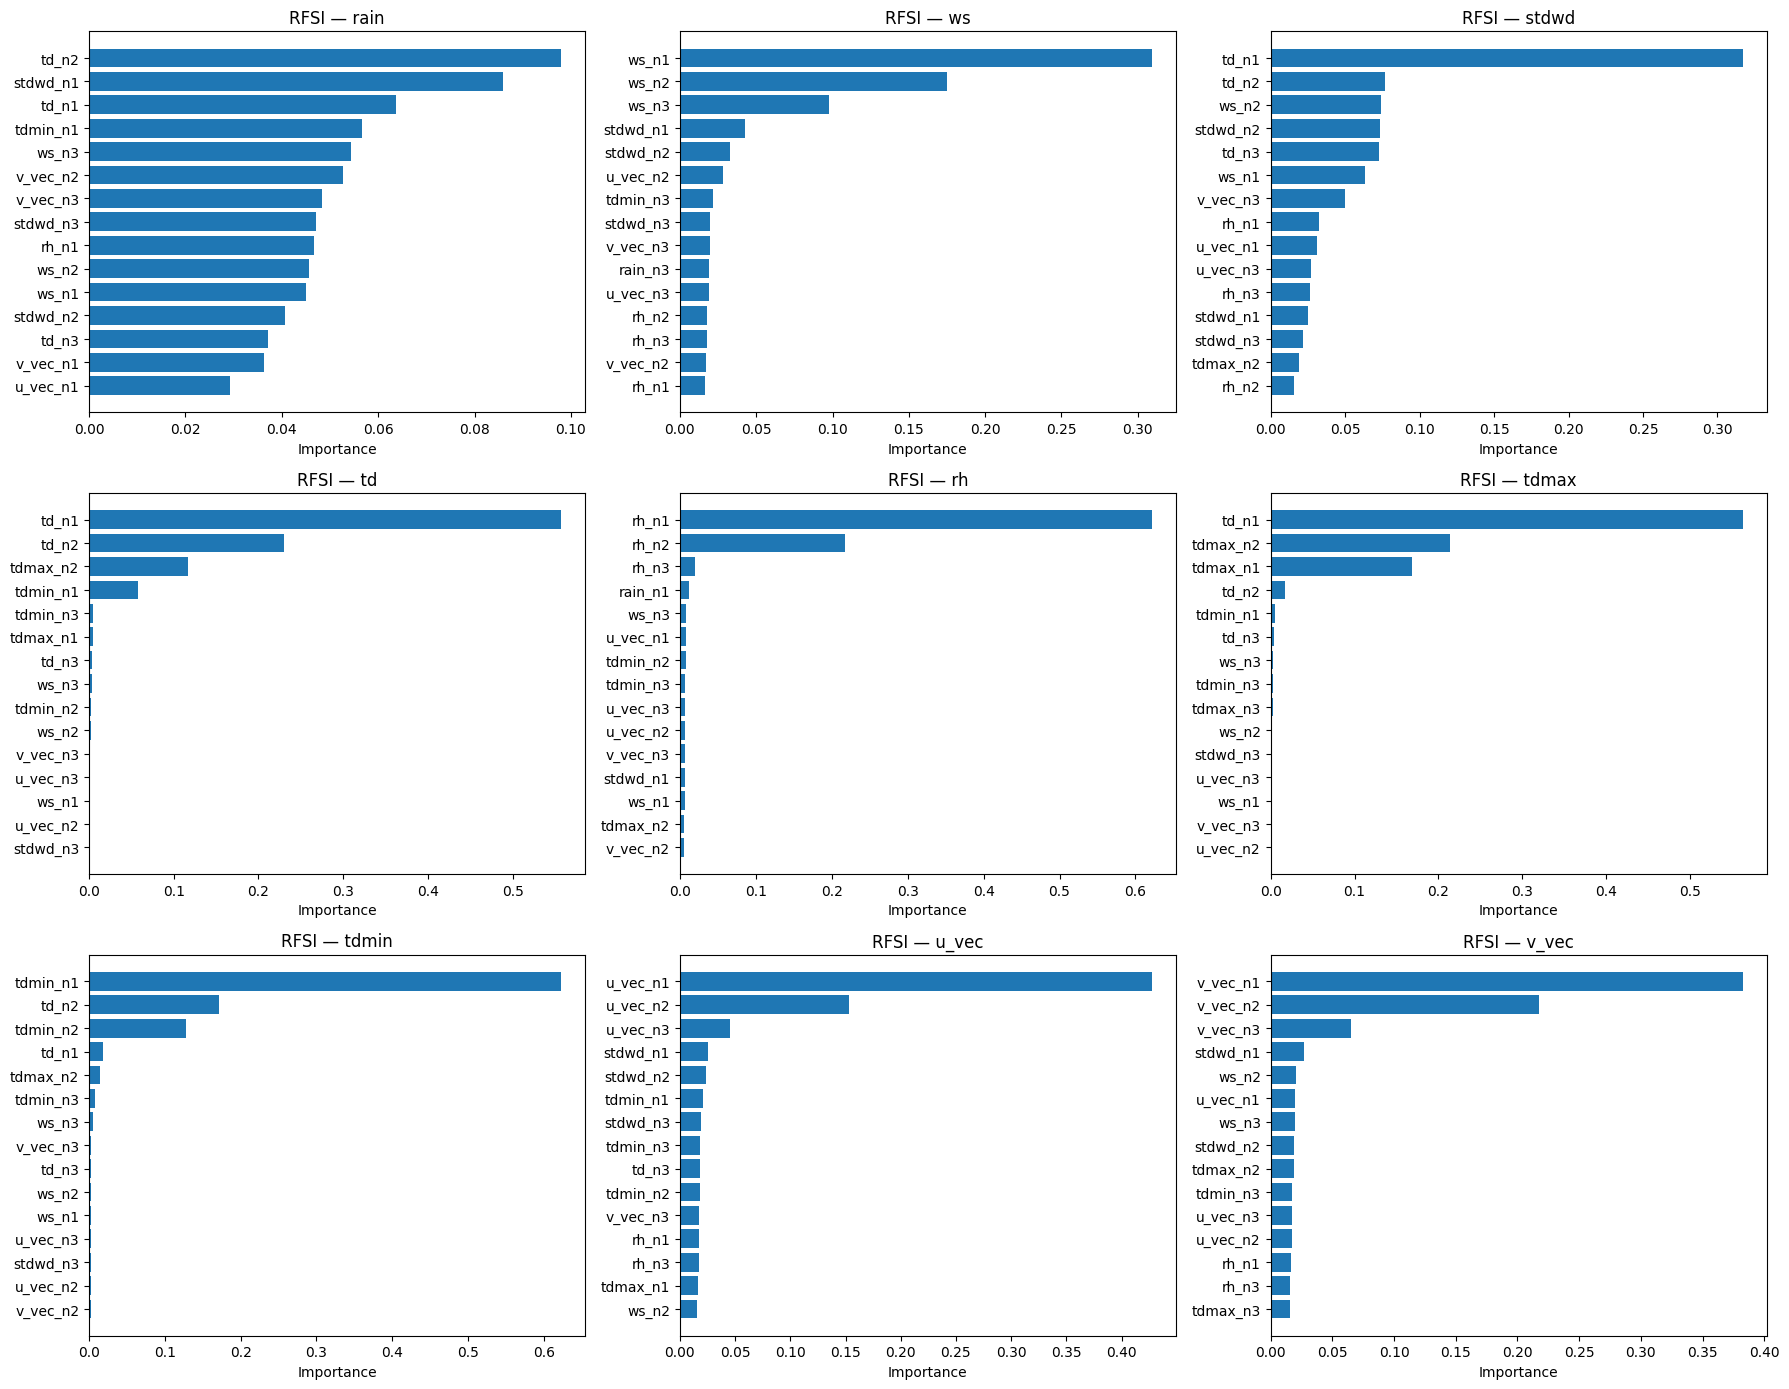

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (feature, model) in enumerate(models.items()):
    importances = model.feature_importances_
    feature_names = X_train.columns
    sorted_idx = importances.argsort()[::-1][:15]  # top 15

    axes[i].barh(feature_names[sorted_idx][::-1], importances[sorted_idx][::-1])
    axes[i].set_title(f'RFSI — {feature}')
    axes[i].set_xlabel('Importance')

plt.tight_layout()
plt.show()
